In [1]:
import matplotlib.pyplot as plt
import numpy as np
from nlmpy import nlmpy

from sensoropt.simulation.landscape import (
    simulate_log_linear_ipp,
    create_grid_layout,
)
from sensoropt.simulation.scr import (
    find_lcp_to_pts,
    simulate_capture_histories
)

This Jupyter Notebook demonstrates how to generate a habitat suitability landscape for an imaginary species. The distribution of individual activity centers across the landscape follows a log-linear inhomogeneous Poisson process.

First, create the habitat suitability raster.

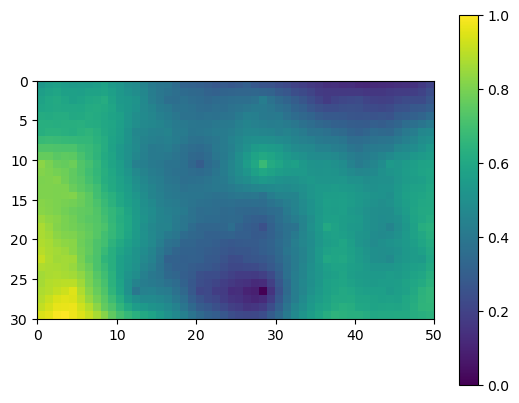

In [2]:
NUM_ROWS = 30 # Rows in the landscape raster
NUM_COLS = 50 # Columns in the landscape raster
N = 100 # Number of individuals to distribute in the landscape
SEED = 42 # Seed for the random number generator

# Generate a landscape raster
rastervals = nlmpy.mpd(NUM_ROWS, NUM_COLS, 1.5)

# Plot the landscape raster
fig, ax = plt.subplots()
img = ax.imshow(rastervals, origin='upper', extent=[0, NUM_COLS, NUM_ROWS, 0])
# NOTE: 1st dimension of the raster is the row, which is the y-axis in the plot
#       2nd dimension of the raster is the column, which is the x-axis in the plot
plt.colorbar(img)
plt.show()

Next, simulate an inhomogeneous Poisson process over the landscape to determine where to place the `N` activity centers. Note that this is a random process, so we can generate multiple realizations of the activity center spatial distributions. Here, we will generate just one realization.

In [3]:
# Simulate the IPP that distributes individual activity centers
n_pixels = np.prod(rastervals.shape)
beta0 = np.log(float(N)/n_pixels)
beta1 = -3 # Negative value makes higher values less likely; positive value makes higher values more likely
num_ac_realizations = 1 # Number of activity center realizations to simulate

ac_realizations = simulate_log_linear_ipp(
    100,
    rastervals,
    beta0,
    beta1,
    n_real=num_ac_realizations,
    seed=SEED
)
ac_realization = ac_realizations[0] # Get the first (and only) activity center realization


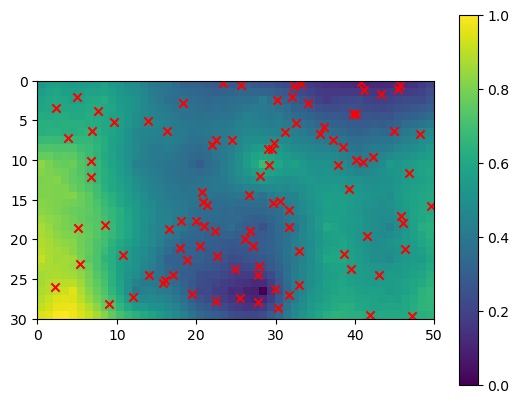

In [4]:
# Plot the activity centers on the landscape
fig, ax = plt.subplots()
img = ax.imshow(rastervals, origin='upper', extent=[0, NUM_COLS, NUM_ROWS, 0])
plt.colorbar(img)

ac_r_coords = [t[0] for t in ac_realization]
ac_c_coords = [t[1] for t in ac_realization]
plt.scatter(ac_c_coords, ac_r_coords, c='r', marker='x')
plt.show()

Next, let's place sensors in a grid layout over the landscape.

Generated a list of 100 trap locations each specified as a tuple of 2 float64s.
e.g. (3.0, 5.0), (3.0, 9.444444444444445), (3.0, 13.88888888888889), ...


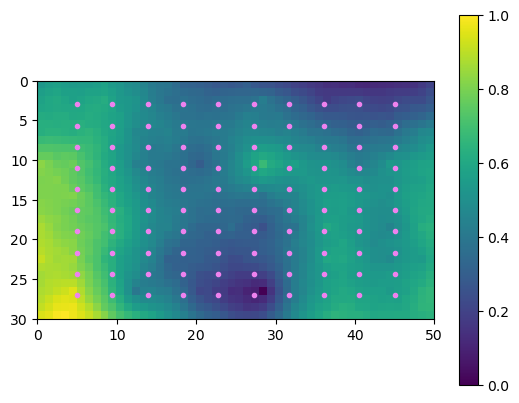

In [5]:
# Generate the trap locations in a grid layout
trap_loc = create_grid_layout(10, 10, rastervals)
print(f"Generated a {type(trap_loc).__name__} of {len(trap_loc)} trap locations",
      f"each specified as a {type(trap_loc[0]).__name__} of {len(trap_loc[0])} {type(trap_loc[0][0]).__name__}s.")
print(f"e.g. {trap_loc[0]}, {trap_loc[1]}, {trap_loc[2]}, ...")

# Plot the trap locations on the landscape
plt.imshow(rastervals, origin='upper', extent=(0, NUM_COLS, NUM_ROWS, 0))
plt.colorbar()
trap_r_coords = [t[0] for t in trap_loc]
trap_c_coords = [t[1] for t in trap_loc]
plt.scatter(trap_c_coords, trap_r_coords, c='violet', marker='.')
plt.show()

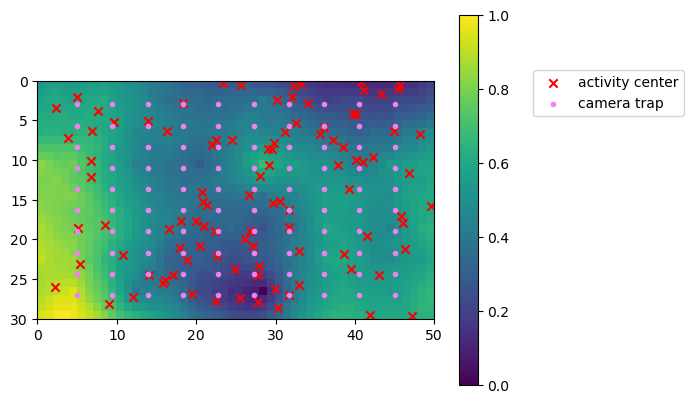

In [6]:
# Visualize activity centers and trap locations together
plt.imshow(rastervals, origin='upper', extent=(0, NUM_COLS, NUM_ROWS, 0))
plt.colorbar()
trap_r_coords = [t[0] for t in trap_loc]
trap_c_coords = [t[1] for t in trap_loc]
plt.scatter(ac_c_coords, ac_r_coords, c='r', marker='x', label='activity center')
plt.scatter(trap_c_coords, trap_r_coords, c='violet', marker='.', label='camera trap')
plt.legend(loc=(1.25,0.85))
plt.show()

Now, let's simulate some capture histories, i.e. detections of each individual in the landscape at each sensor. This simulation uses spatial capture-recapture parameters and least cost path distances. Note again that this is a random process, so we can generate different random capture histories for a given set of activity centers. Here, we generate just one.

In [7]:
ALPHA0 = -5 # SCR parameter affecting the detection probability; -5 gives unrealistically high detection probability of ~99%; 1 is more realistic
ALPHA1 = 3.369959 # SCR parameter affecting home range size
ALPHA2 = 2.25 # SCR scale parameter affecting how a pixel's habitat suitability value affects movement cost
K = 10
num_caphist_realizations = 1

lcp_distances = find_lcp_to_pts(rastervals, ALPHA2, trap_loc, raster_cell_size=0.1)
cap_hists = simulate_capture_histories(
    ac_realization,
    trap_loc,
    K,
    lcp_distances,
    ALPHA0,
    ALPHA1,
    num_caphist_realizations,
    seed=SEED
)
cap_hist = cap_hists[0] # Get the first (and only) capture history realization
        

`cap_hist` is an ndarray of shape (96, 100) where the number of rows is the number of detected individuals and the number of columns is the number of traps.
Detected individual 53 was detected at traps [30 40]
[(11.0, 5.0), (13.666666666666666, 5.0)]


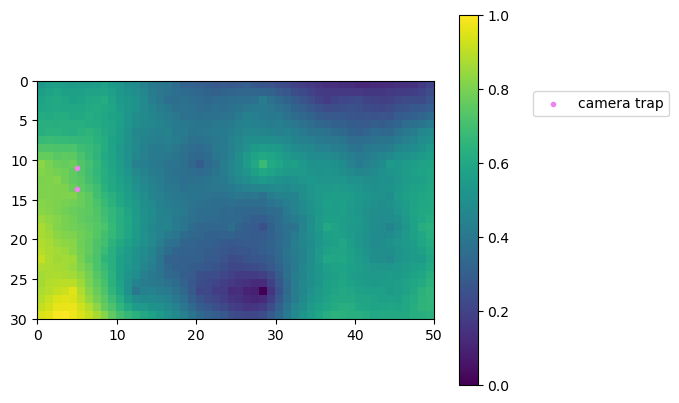

In [ ]:
print(f"`cap_hist` is an {type(cap_hist).__name__} of shape {cap_hist.shape}",
      f"where the number of rows is the number of detected individuals and the number of columns is the number of traps.")   

# Plot the locations of detections for one individual
detected_ind_idx = 53
ind_cap_hist = cap_hist[detected_ind_idx]
ind_trap_locs = np.where(ind_cap_hist != 0)[0]
print(f"Detected individual {detected_ind_idx} was detected at traps {ind_trap_locs}")

# Plot the individual's activity center and the trap locations where it was detected
plt.imshow(rastervals, origin='upper', extent=(0, NUM_COLS, NUM_ROWS, 0))
plt.colorbar()
# Subset trap locations to only traps with detections of the individual
trap_r_coords = [trap_loc[i][0] for i in ind_trap_locs]
trap_c_coords = [trap_loc[i][1] for i in ind_trap_locs]
# print(list(zip(trap_r_coords, trap_c_coords)))
plt.scatter(trap_c_coords, trap_r_coords, c='violet', marker='.', label='camera trap')
plt.legend(loc=(1.25,0.85))
plt.show()